In [14]:
import os
import re
import requests
import arxiv as arxiv_lib
from dotenv import load_dotenv
from typing import List
from pydantic import BaseModel
from langchain.tools import tool
from langchain_core.tools import Tool
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_ollama import OllamaEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_community.document_loaders.youtube import YoutubeLoader
from langchain_community.document_loaders import ArxivLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END
from langfuse.langchain import CallbackHandler
from langchain_tavily import TavilySearch


load_dotenv()

langfuse_trace = CallbackHandler()

In [15]:
from typing import Annotated

openai_llm = init_chat_model("openai:gpt-4o-mini")
ollama_llm = init_chat_model(
    model="granite4",
    model_provider="ollama"
)
google_llm = init_chat_model(
    model="gemini-2.5-flash-lite",
    model_provider="google_genai",
)

In [16]:
tavily_tool = TavilySearch(max_results=2)

In [17]:
### generic function to create a retrieval tool

def make_retriever_tool_from_text(file, name, desc):
    docs = TextLoader(
        file,
        encoding="utf-8"
    ).load()
    chunks = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=50,
    ).split_documents(docs)
    vs = FAISS.from_documents(chunks, OllamaEmbeddings(
        model="nomic-embed-text"
    ))
    retriever = vs.as_retriever()

    def tool_func(query: str) -> str:
        print(f"Using tool: {name}")
        results = retriever.invoke(query, config={"callbacks": [langfuse_trace]})
        return "\n\n".join(doc.page_content for doc in results)
    
    return Tool(
        name=name,
        description=desc,
        func=tool_func
    )

internal_tool_1 = make_retriever_tool_from_text(
    "internal_docs.txt",
    "InternalResearchNote",
    "Search internal research notes for experimental results"
)

internal_tool_1

Tool(name='InternalResearchNote', description='Search internal research notes for experimental results', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x00000234D8540D60>)

In [18]:
from langchain_core.messages import BaseMessage, HumanMessage
from langchain.agents import create_agent
from langgraph.graph import MessagesState, END
from langgraph.types import Command

def get_next_node(last_message: BaseMessage, goto: str):
    if "FINAL ANSWER" in last_message.content:
        return END
    return goto

In [ ]:
def make_system_prompt(suffix: str) -> str:
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{suffix}"
    )

In [ ]:
### Reaearch agent and node

research_agent = create_agent(
    ollama_llm,
    # openai_llm,
    tools=[internal_tool_1, tavily_tool],
    system_prompt=make_system_prompt("You can only do research. Use the tool that you are binded with, you can use both of them" \
    " You are working with a content writer colleague.")
)
research_agent

In [ ]:
from typing import Literal

# Research node
def research_node(state: MessagesState) -> Command[Literal["blog_generator", END]]:
    result = research_agent.invoke(
        state,
        config={"callbacks": [langfuse_trace]}
    )
    goto = get_next_node(
        result["messages"][-1],
        "blog_generator"
    )
     # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content,
        name="researcher"
    )
    return Command(
        update={
            # share internal message history of research agent with other agents
            "messages": result["messages"],
        },
        goto=goto
    )

In [ ]:
### Blog write agent
blog_agent = create_agent(
    google_llm,
    tools=[],
    system_prompt=make_system_prompt(
        "You can only write a detailed blog. You are working with a researcher colleague."
    )
)

def blog_node(state: MessagesState) -> Command[Literal["researcher", END]]:
    result = blog_agent.invoke(state, config={
        "callbacks": [langfuse_trace]
    })
    goto = get_next_node(result["messages"][-1], "researcher")
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="blog_generator"
    )
    return Command(
        update={
            # share internal message history of chart agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )

In [ ]:
from langgraph.graph import StateGraph, START

workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("blog_generator", blog_node)

workflow.add_edge(START, "researcher")
graph = workflow.compile()
graph

In [ ]:
response=graph.invoke(
    {"messages":"Write a detailed blog on transformer variants in production deployments"},
    config={"callbacks": [langfuse_trace]}
)
response["messages"][-1].content

In [ ]:
internal_tool_1

### Multi Agent Suprvisor With RAG

In [5]:
from langchain_tavily import TavilySearch

web_search = TavilySearch(max_results=2)
web_search

TavilySearch(max_results=2, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

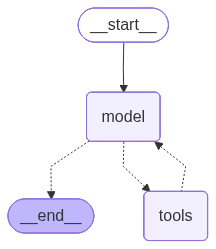

In [6]:
research_agent=create_agent(
    model=ollama_llm,
    tools=[web_search,internal_tool_1],
    system_prompt=(
        "You are a research agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related tasks, DO NOT do any math\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="research_agent"
)
research_agent

In [7]:
def add(a: float, b: float):
    """Add two numbers."""
    return a + b


def multiply(a: float, b: float):
    """Multiply two numbers."""
    return a * b


def divide(a: float, b: float):
    """Divide two numbers."""
    return a / b


math_agent=create_agent(
    model=ollama_llm,
    tools=[add,multiply,divide],
    system_prompt=(
        "You are a math agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with math-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="math_agent"
)

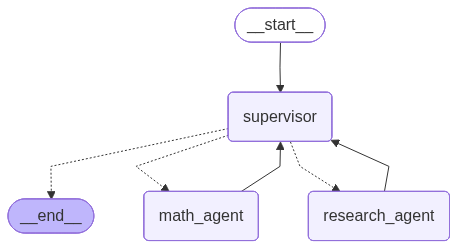

In [8]:
### create supervisor agent
from langgraph_supervisor import create_supervisor

supervisor=create_supervisor(
    model=ollama_llm,
    agents=[research_agent,math_agent],
    prompt=(
         "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research-related tasks to this agent\n"
        "- a math agent. Assign math-related tasks to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."

    ),
    add_handoff_back_messages=True,
    output_mode="full_history"
).compile()

supervisor

In [9]:
response=supervisor.invoke(
    {"messages":" list all the transformer variants in production deployments from the retriever and then tell me what is 5 plus 10"},
    config={"callbacks": [langfuse_trace]}
)

Using tool: InternalResearchNote


In [10]:
response

{'messages': [HumanMessage(content=' list all the transformer variants in production deployments from the retriever and then tell me what is 5 plus 10', additional_kwargs={}, response_metadata={}, id='3d96f66e-98d4-4296-9b23-2ce2c8f8da52'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'granite4', 'created_at': '2026-06-29T07:44:14.556389693Z', 'done': True, 'done_reason': 'stop', 'total_duration': 35214630125, 'load_duration': 29747200706, 'prompt_eval_count': 277, 'prompt_eval_duration': 3807037000, 'eval_count': 19, 'eval_duration': 1655939000, 'logprobs': None, 'model_name': 'granite4', 'model_provider': 'ollama'}, name='supervisor', id='lc_run--019f1255-794a-7fd0-9399-be897d11d1ec-0', tool_calls=[{'name': 'transfer_to_research_agent', 'args': {}, 'id': 'ffa2bd60-7d15-479e-b9de-a474d5086ca4', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 277, 'output_tokens': 19, 'total_tokens': 296}),
  ToolMessage(content='Successfully t

### Hierarchical Agent Teams With RAG

In [19]:
from typing import Annotated, List

from langchain_community.document_loaders import WebBaseLoader
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

tavily_tool = TavilySearch(max_results=2)

In [20]:
@tool
def scrape_webpages(urls:List[str])->str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    loader = WebBaseLoader(urls)
    docs = loader.load()
    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</Document>'
            for doc in docs
        ]
    )


In [36]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional
from typing_extensions import TypedDict

# NOTE: `langchain_experimental` is being sunset, so we no longer import
# `PythonREPL` from it. Instead we define a minimal, self-contained REPL
# (same behaviour: exec the code and capture stdout).
import sys
import re
from io import StringIO


class PythonREPL:
    """A minimal Python REPL that executes code and captures stdout.

    Drop-in replacement for ``langchain_experimental.utilities.PythonREPL``.
    WARNING: this executes arbitrary code locally and is unsafe when not
    sandboxed.
    """

    def __init__(self, _globals: Optional[dict] = None, _locals: Optional[dict] = None):
        self.globals = _globals if _globals is not None else {}
        self.locals = _locals if _locals is not None else {}

    @staticmethod
    def sanitize_input(query: str) -> str:
        # Remove leading/trailing whitespace and optional ```python ... ``` fences.
        query = re.sub(r"^(\s|`)*(?i:python)?\s*", "", query)
        query = re.sub(r"(\s|`)*$", "", query)
        return query

    def run(self, command: str, timeout: Optional[int] = None) -> str:
        command = self.sanitize_input(command)
        old_stdout = sys.stdout
        sys.stdout = mystdout = StringIO()
        try:
            exec(command, self.globals, self.locals)
            output = mystdout.getvalue()
        except Exception as e:
            output = repr(e)
        finally:
            sys.stdout = old_stdout
        return output


_TEMP_DIRECTORY = TemporaryDirectory()
WORKING_DIRECTORY = Path(_TEMP_DIRECTORY.name)

@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""
    with (WORKING_DIRECTORY / file_name).open("w", encoding="utf-8") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"

@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    """Create and save a text document."""
    with (WORKING_DIRECTORY / file_name).open("w", encoding="utf-8") as file:
        file.write(content)
    return f"Document saved to {file_name}"

@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ],
) -> Annotated[str, "Path of the edited document file."]:
    """Edit a document by inserting text at specific line numbers."""

    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."

    with (WORKING_DIRECTORY / file_name).open("w", encoding="utf-8") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"

In [37]:
WORKING_DIRECTORY

WindowsPath('C:/Users/THOLE~1/AppData/Local/Temp/tmpdsepe1jf')

In [38]:
# Warning: This executes code locally, which can be unsafe when not sandboxed

repl = PythonREPL()


@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"

In [39]:
from typing import List, Optional, Literal
from langchain_core.language_models.chat_models import BaseChatModel

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.types import Command
from langchain_core.messages import HumanMessage, trim_messages


class State(MessagesState):
    next: str

In [40]:
def make_supervisor_node(llm: BaseChatModel, members: list[str]) -> str:
    options = ["FINISH"] + members
    system_prompt = (
        "You are a supervisor tasked with managing a conversation between the"
        f" following workers: {members}. Given the following user request,"
        " respond with the worker to act next. Each worker will perform a"
        " task and respond with their results and status. When finished,"
        " respond with FINISH."
    )

    class Router(TypedDict):
        """Worker to route to next. If no workers needed, route to FINISH."""

        next: Literal[*options]

    def supervisor_node(state: State) -> Command[Literal[*members, "__end__"]]:
        """An LLM-based router."""
        messages = [
            {"role": "system", "content": system_prompt},
        ] + state["messages"]
        response = llm.with_structured_output(Router).invoke(messages, config={"callbacks": [langfuse_trace]})
        goto = response["next"]
        if goto == "FINISH":
            goto = END

        return Command(goto=goto, update={"next": goto})

    return supervisor_node

In [41]:
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent


search_agent = create_agent(ollama_llm, tools=[tavily_tool,internal_tool_1])
search_agent

def search_node(state: State) -> Command[Literal["supervisor"]]:
    result = search_agent.invoke(state, config={"callbacks": [langfuse_trace]})
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="search")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

### sub agent
web_scraper_agent = create_agent(ollama_llm, tools=[scrape_webpages])


def web_scraper_node(state: State) -> Command[Literal["supervisor"]]:
    result = web_scraper_agent.invoke(state, config={"callbacks": [langfuse_trace]})
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="web_scraper")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

In [42]:
research_supervisor_node = make_supervisor_node(ollama_llm, ["search", "web_scraper"])
research_supervisor_node

<function __main__.make_supervisor_node.<locals>.supervisor_node(state: __main__.State) -> langgraph.types.Command[typing.Literal['search', 'web_scraper', '__end__']]>

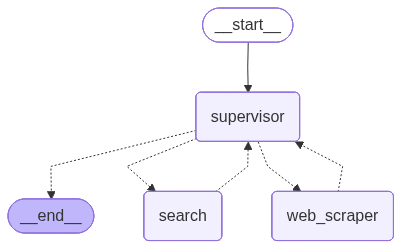

In [43]:
research_builder = StateGraph(State)
research_builder.add_node("supervisor", research_supervisor_node)
research_builder.add_node("search", search_node)
research_builder.add_node("web_scraper", web_scraper_node)

research_builder.add_edge(START, "supervisor")
research_graph = research_builder.compile()
research_graph

In [44]:
@tool
def read_document(
    file_name: Annotated[str, "File path to read the document from."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])

In [45]:
doc_writer_agent = create_agent(
    ollama_llm,
    tools=[write_document, edit_document, read_document],
    system_prompt=(
        "You can read, write and edit documents based on note-taker's outlines. "
        "Don't ask follow-up questions."
    ),
)


def doc_writing_node(state: State) -> Command[Literal["supervisor"]]:
    result = doc_writer_agent.invoke(state, config={"callbacks": [langfuse_trace]})
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="doc_writer")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

note_taking_agent = create_agent(
    ollama_llm,
    tools=[create_outline, read_document],
    system_prompt=(
        "You can read documents and create outlines for the document writer. "
        "Don't ask follow-up questions."
    ),
)


def note_taking_node(state: State) -> Command[Literal["supervisor"]]:
    result = note_taking_agent.invoke(state, config={"callbacks": [langfuse_trace]})
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="note_taker")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )


chart_generating_agent = create_agent(
    ollama_llm, tools=[read_document, python_repl_tool]
)


def chart_generating_node(state: State) -> Command[Literal["supervisor"]]:
    result = chart_generating_agent.invoke(state, config={"callbacks": [langfuse_trace]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=result["messages"][-1].content, name="chart_generator"
                )
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

doc_writing_supervisor_node = make_supervisor_node(
    ollama_llm, ["doc_writer", "note_taker", "chart_generator"])

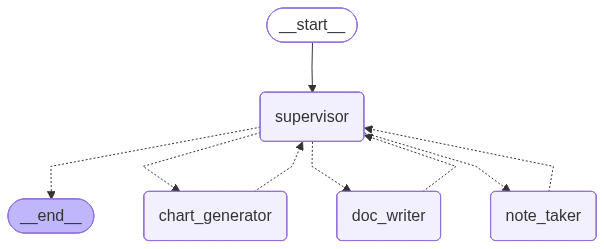

In [49]:
# Create the graph here
paper_writing_builder = StateGraph(State)
paper_writing_builder.add_node("supervisor", doc_writing_supervisor_node)
paper_writing_builder.add_node("doc_writer", doc_writing_node)
paper_writing_builder.add_node("note_taker", note_taking_node)
paper_writing_builder.add_node("chart_generator", chart_generating_node)

paper_writing_builder.add_edge(START, "supervisor")
paper_writing_graph = paper_writing_builder.compile()
paper_writing_graph

In [51]:
from langchain_core.messages import BaseMessage
teams_supervisor_node = make_supervisor_node(ollama_llm, ["research_team", "writing_team"])
teams_supervisor_node

<function __main__.make_supervisor_node.<locals>.supervisor_node(state: __main__.State) -> langgraph.types.Command[typing.Literal['research_team', 'writing_team', '__end__']]>

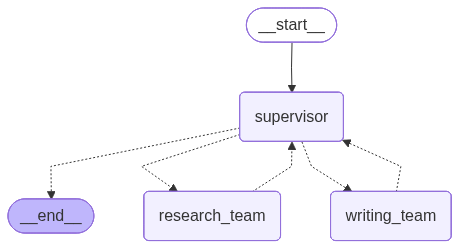

In [52]:
def call_research_team(state: State) -> Command[Literal["supervisor"]]:
    response = research_graph.invoke({"messages": state["messages"][-1]}, config={'callbacks': [langfuse_trace]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content, name="research_team"
                )
            ]
        },
        goto="supervisor",
    )


def call_paper_writing_team(state: State) -> Command[Literal["supervisor"]]:
    response = paper_writing_graph.invoke({"messages": state["messages"][-1]}, config={'callbacks': [langfuse_trace]})
    return Command(
        update={
            "messages": [
                HumanMessage(
                    content=response["messages"][-1].content, name="writing_team"
                )
            ]
        },
        goto="supervisor",
    )


# Define the graph.
super_builder = StateGraph(State)
super_builder.add_node("supervisor", teams_supervisor_node)
super_builder.add_node("research_team", call_research_team)
super_builder.add_node("writing_team", call_paper_writing_team)

super_builder.add_edge(START, "supervisor")
super_graph = super_builder.compile()
super_graph

In [ ]:
response=super_graph.invoke(
    {
        "messages": [
            ("user", "Write about transformer variants in production deployments.")
        ],
    }, config={'callbacks': [langfuse_trace]})

Using tool: InternalResearchNote


In [ ]:
response["messages"][-1].content